In [7]:
#imports
import sys
sys.path.insert(0, '..')

from src.hawkes_lob.data import fetch_trades, extract_event_times, describe_trades
from src.hawkes_lob.hawkes import fit_hawkes, simulate_hawkes, plot_intensity
import matplotlib.pyplot as plt
import numpy as np

In [8]:
#fetch data
df = fetch_trades(symbol='ETH/BTC', n_trades=1000)
describe_trades(df)

Fetching 1000 trades for ETH/BTC...
Saved to data/raw/ETH_BTC_trades.csv
Total trades     : 1000
Time window      : 6841.7 seconds (114.0 minutes)
Buy trades       : 645 (64.5%)
Sell trades      : 355 (35.5%)
Avg trade rate   : 0.15 trades/second
Price range      : 0.03 — 0.03


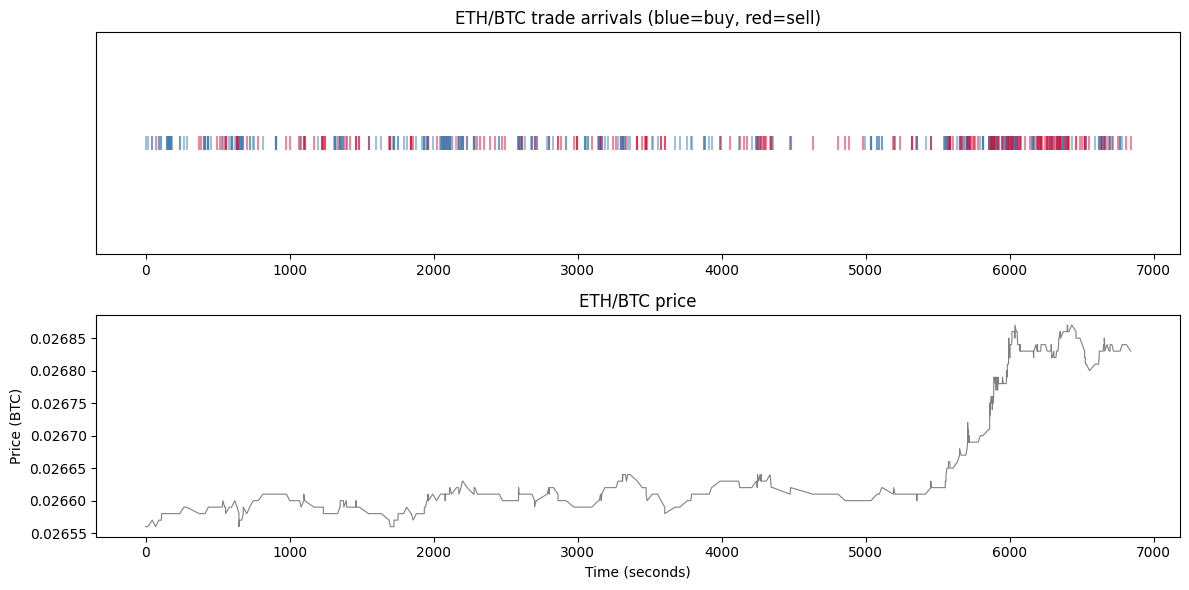

In [13]:
#visualise raw trade flow
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Trade arrivals
axes[0].scatter(df['timestamp'] - df['timestamp'].iloc[0],
                [1]*len(df), marker='|', s=100,
                c=['steelblue' if s=='buy' else 'crimson' for s in df['side']],
                alpha=0.5)
axes[0].set_title('ETH/BTC trade arrivals (blue=buy, red=sell)')
axes[0].set_yticks([])

# Price
axes[1].plot(df['timestamp'] - df['timestamp'].iloc[0],
             df['price'], color='gray', linewidth=0.8)
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Price (BTC)')
axes[1].set_title('ETH/BTC price')

plt.tight_layout()
plt.show()

In [10]:
#fit Hawkes on all trades
events, T = extract_event_times(df, side='both')
print(f"\nFitting Hawkes on {len(events)} events over T={T:.1f}s...")

result = fit_hawkes(events.tolist(), T=T)

print(f"\n--- Fitted parameters ---")
print(f"mu    (baseline intensity) : {result['mu']:.4f} trades/second")
print(f"alpha (jump size)          : {result['alpha']:.4f}")
print(f"beta  (decay speed)        : {result['beta']:.4f}")
print(f"eta   (branching ratio)    : {result['branching_ratio']:.4f}")
print(f"E[λ]  (mean intensity)     : {result['mu']/(1-result['branching_ratio']):.4f} trades/second")


Fitting Hawkes on 1000 events over T=6841.7s...

--- Fitted parameters ---
mu    (baseline intensity) : 0.0812 trades/second
alpha (jump size)          : 25.4618
beta  (decay speed)        : 57.1890
eta   (branching ratio)    : 0.4452
E[λ]  (mean intensity)     : 0.1463 trades/second


In [11]:
#compare buy vs sell branching ratios
events_buy,  T_buy  = extract_event_times(df, side='buy')
events_sell, T_sell = extract_event_times(df, side='sell')

result_buy  = fit_hawkes(events_buy.tolist(),  T=T_buy)
result_sell = fit_hawkes(events_sell.tolist(), T=T_sell)

print(f"\n--- Buy side ---")
print(f"eta = {result_buy['branching_ratio']:.4f}")

print(f"\n--- Sell side ---")
print(f"eta = {result_sell['branching_ratio']:.4f}")

print(f"\nAsymmetry (sell eta / buy eta): {result_sell['branching_ratio']/result_buy['branching_ratio']:.3f}")


--- Buy side ---
eta = 0.5495

--- Sell side ---
eta = 0.2105

Asymmetry (sell eta / buy eta): 0.383


In [12]:
# Empirical rate
empirical_rate = len(events) / T

# Model-implied rate
model_rate = result['mu'] / (1 - result['branching_ratio'])

print(f"Empirical rate   : {empirical_rate:.4f} trades/second")
print(f"Model-implied    : {model_rate:.4f} trades/second")
print(f"Relative error   : {abs(empirical_rate - model_rate)/empirical_rate*100:.1f}%")

Empirical rate   : 0.1462 trades/second
Model-implied    : 0.1463 trades/second
Relative error   : 0.1%


In [14]:
# --- Regime comparison : BTC/USDT vs ETH/BTC on June 8, 2026 @ around 09:30 PM UTC ---
#
# BTC/USDT (1 minute window)
#   - 16.3 trades/second — ultra-liquid HFT market
#   - Price move: $70 in 60s — strongly non-stationary
#   - Model-implied E[λ]: 30.7 vs empirical 16.3 → 88% error
#   - Conclusion: Hawkes stationary model misspecified on BTC/USDT spot
#
# ETH/BTC (114 minute window)  
#   - 0.15 trades/second — less liquid, slower dynamics
#   - Price move: 0.03 → 0.03 BTC — quasi-stationary over most of window
#   - Model-implied E[λ]: 0.1463 vs empirical 0.1462 → 0.1% error
#   - Fitted: mu=0.081, alpha=25.46, beta=57.19, eta=0.445
#   - Conclusion: model well-specified, parameters interpretable
#
# Key insight: Hawkes univariate stationary model requires:
#   1. Low trade frequency (< 1-2 trades/second)
#   2. Quasi-stationary price dynamics
#   3. Sufficient observation window (> 30 minutes)

In [15]:
print("Calibrated parameters to save in config.py:")
print(f"  'mu':    {result['mu']:.4f},")
print(f"  'alpha': {result['alpha']:.4f},")
print(f"  'beta':  {result['beta']:.4f},")
print(f"  'eta':   {result['branching_ratio']:.4f},")
print(f"  'mean_intensity': {result['mu']/(1-result['branching_ratio']):.4f},")

Calibrated parameters to save in config.py:
  'mu':    0.0812,
  'alpha': 25.4618,
  'beta':  57.1890,
  'eta':   0.4452,
  'mean_intensity': 0.1463,
